In [1]:
import pandas as pd
import numpy as np

In [10]:
fall1=pd.read_csv("C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F01/U03_R01_accel.csv",header=0)
fall2=pd.read_csv("C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F01/U03_R02_accel.csv",header=0)

In [2]:
def get_values_around_max(series):
    """
    Returns the 20 values before and after the maximum value in the given Pandas Series.
    If there are not 20 values before or after the maximum, it will return None.
    """
    max_value = series.max()
    max_index = series.idxmax()

    start = max_index - 20
    end = max_index + 21

    if start < 0 or end > len(series):
        return None

    return series.iloc[start:end]

<Axes: title={'center': 'accel_5_list'}>

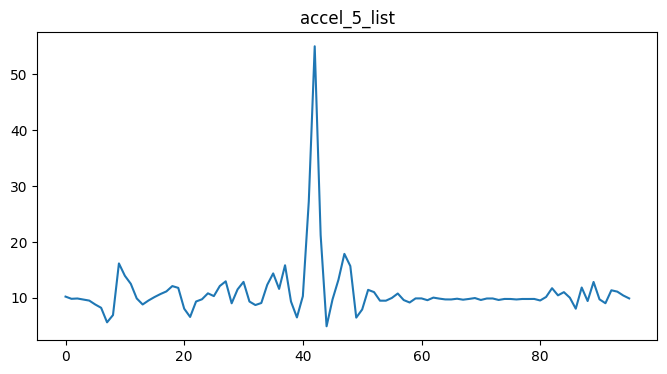

In [11]:
from matplotlib import pyplot as plt
import math
t=np.sqrt(fall1['accel_x_list']**2+fall1['accel_y_list']**2+fall1['accel_z_list']**2)
t.plot(kind='line', figsize=(8, 4), title='accel_5_list')

In [4]:
type(t)

pandas.core.series.Series

<Axes: title={'center': 'accel_5_list'}>

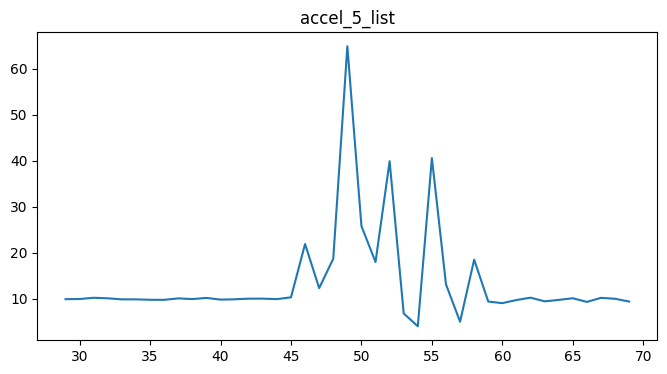

In [12]:
get_values_around_max(t).plot(kind='line', figsize=(8, 4), title='accel_5_list')

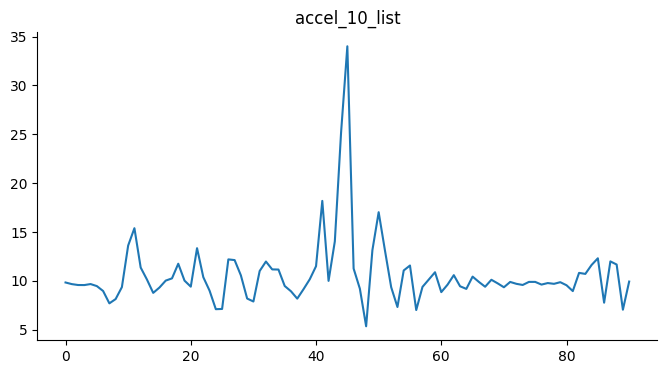

In [12]:
t1=np.sqrt(fall2['accel_x_list']**2+fall2['accel_y_list']**2+fall2['accel_z_list']**2)
t1.plot(kind='line', figsize=(8, 4), title='accel_10_list')
plt.gca().spines[['top', 'right']].set_visible(False)

TypeError: Invalid shape (41,) for image data

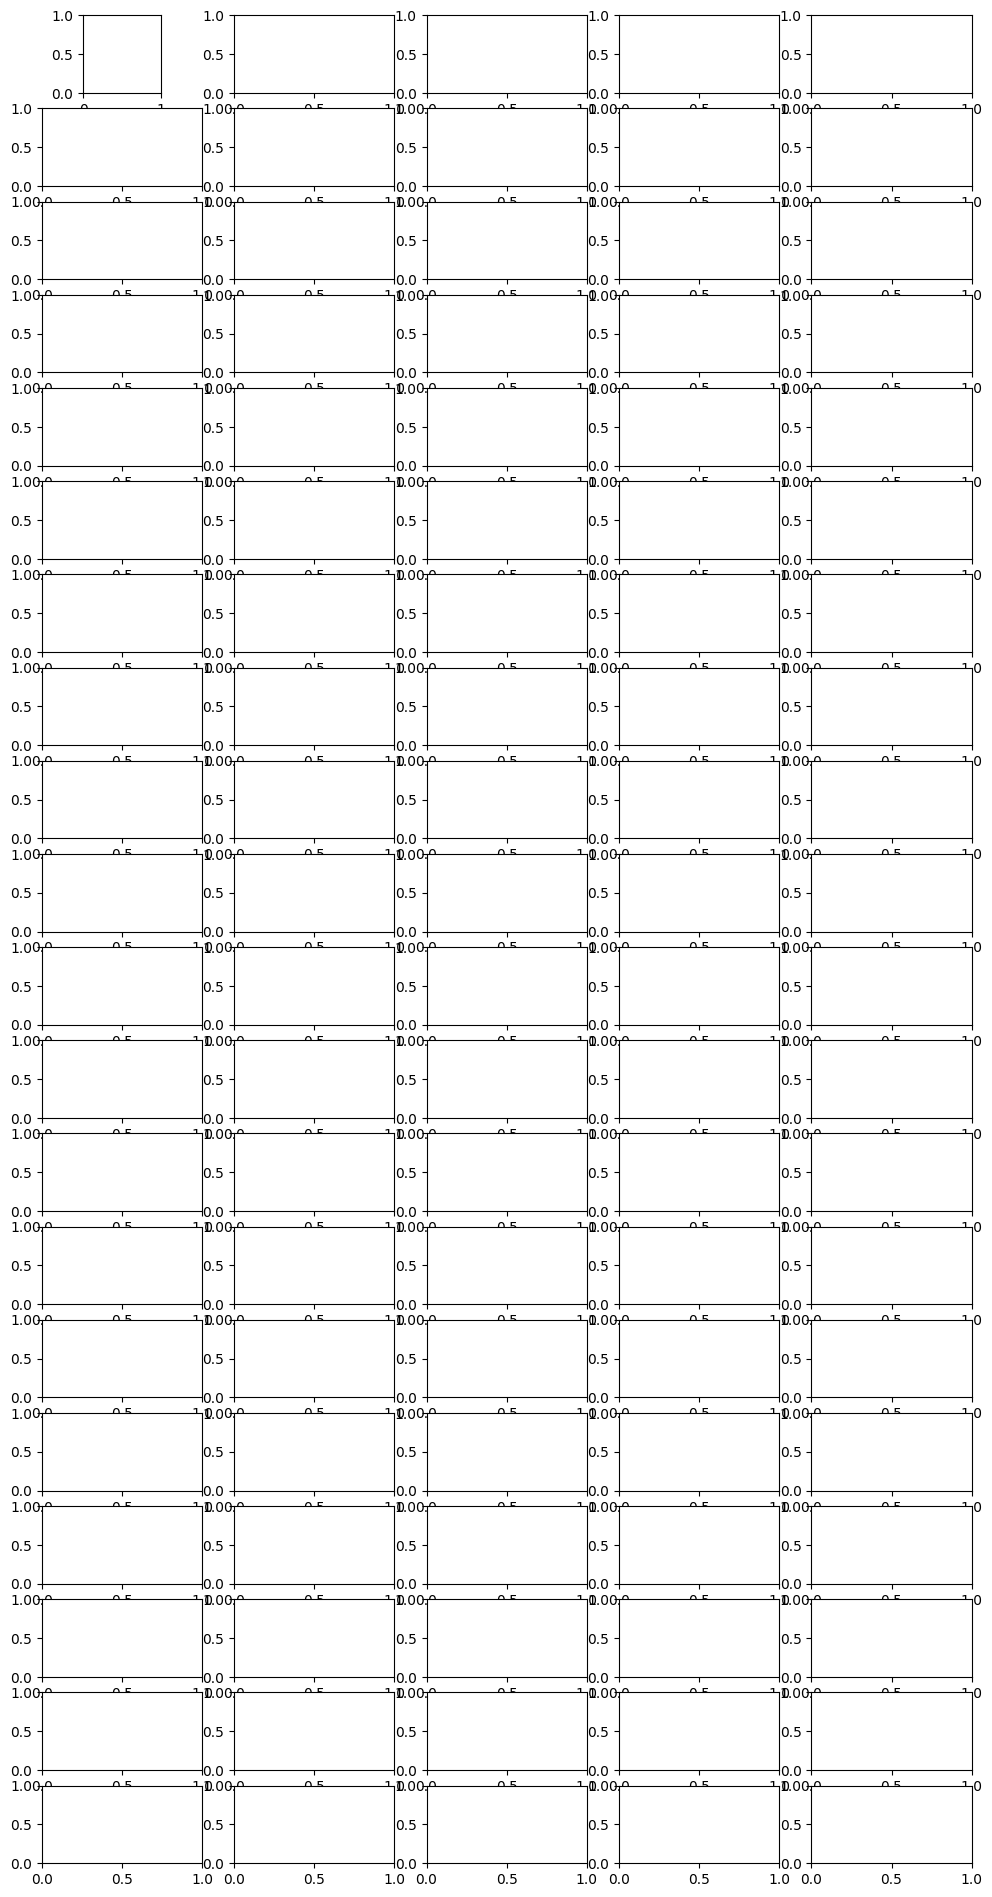

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have an array 'data' with shape (100, 41)
data = np.random.rand(100, 41)

# Set up the figure and subplot layout
fig, axes = plt.subplots(20, 5, figsize=(12, 24))

# Loop through each line and draw the pictures
for i in range(20):
    for j in range(5):
        ax = axes[i, j]
        ax.imshow(data[i*5+j], cmap='gray')
        ax.axis('off')

plt.tight_layout()
plt.show()

C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/D07/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/D07/U02_R01_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/D07/U04_R03_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/D07/U08_R02_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/D07/U10_R02_accel.csv


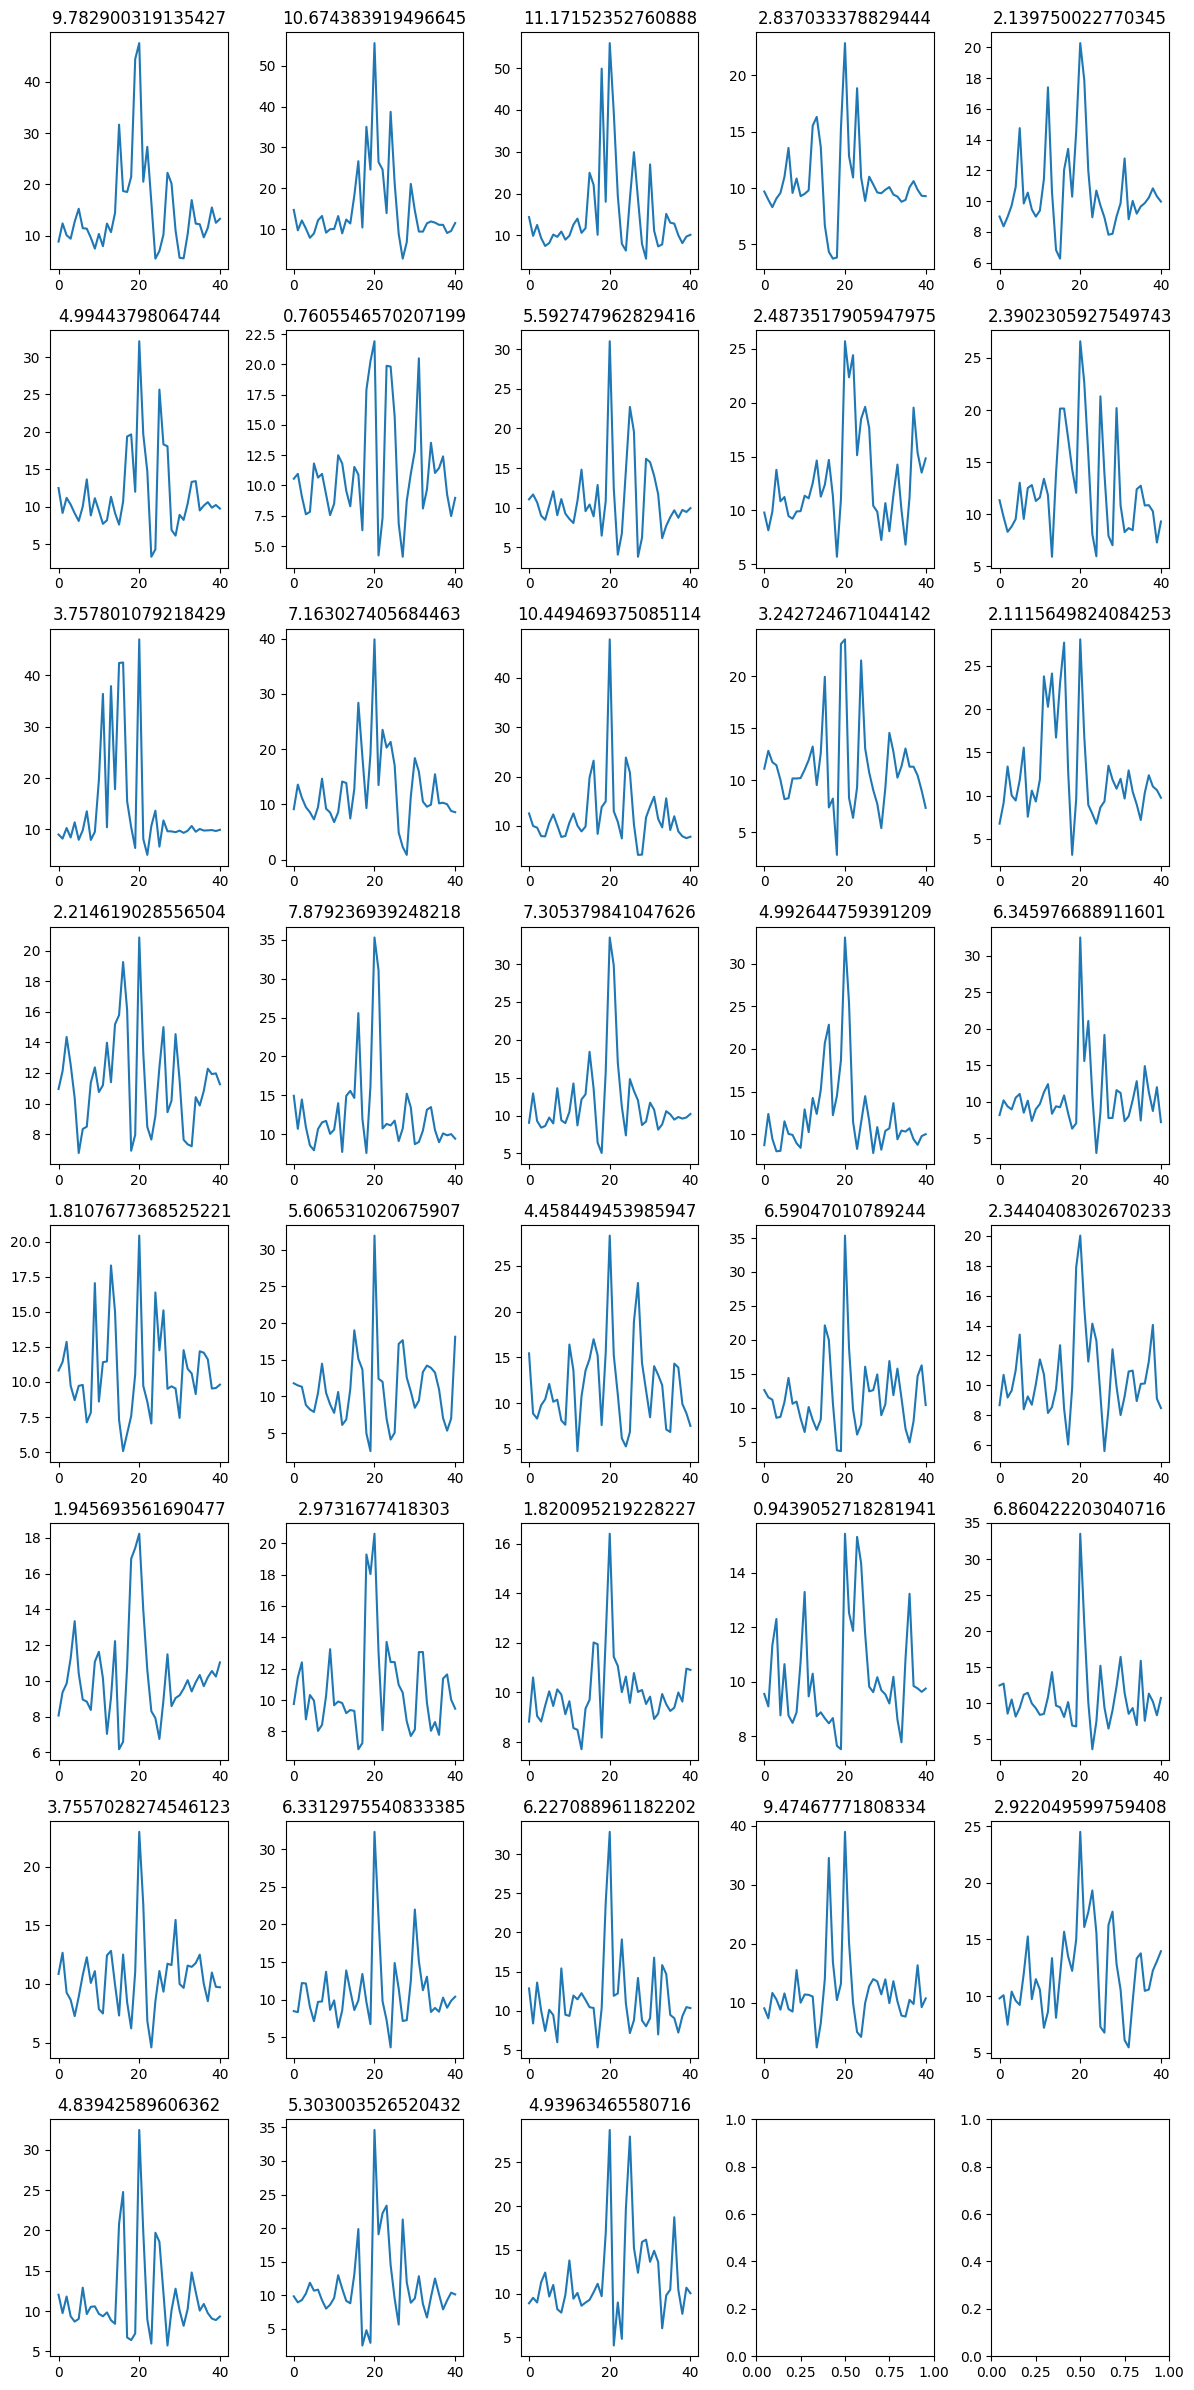

In [35]:
import os
import numpy as np
from pandas import read_csv
from numpy import dstack
from matplotlib import pyplot as plt
import statistics
def get_values_around_max(series):
    """
    Returns the 20 values before and after the maximum value in the given Pandas Series.
    If there are not 20 values before or after the maximum, it will return None.
    """
    max_value = series.max()
    max_index = series.idxmax()

    start = max_index - 20
    end = max_index + 21

    if start < 0 or end > len(series):
        return None

    return series.iloc[start:end]
# load a single file as a numpy array
def load_file(filepath):
  fall = read_csv(filepath, header=0)
  t=np.sqrt(fall['accel_x_list']**2+fall['accel_y_list']**2+fall['accel_z_list']**2)
  return get_values_around_max(t)

# load a list of files and return as a 3d numpy array
def load_group(filenames, prefix=''):
  loaded = []
  for name in filenames:
    data = load_file(prefix + name)
    if data is None:
       print(name)
    else:
      loaded.append(data.tolist())
      #loaded = dstack(loaded)
  # stack group so that features are the 3rd dimension
  #loaded = dstack(loaded)
  return loaded

def get_files_in_dir(directory, file_pattern='accel.csv'):
    """
    Returns a list of all files in the given directory that match the file_pattern.
    """
    file_list = []
    print(directory)
    for filename in os.listdir(directory):
        if filename.endswith(file_pattern):
            file_list.append(os.path.join(directory, filename))
    return file_list

# load a dataset group, such as train or test
def load_dataset_group(group, prefix='C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/'):
#def load_dataset_group(group, prefix='/Users/song/Downloads/WEDA-FALL/dataset/10Hz/'):  
  filepath = prefix + group + '/'
  # load all 9 files as a single array
  filenames = get_files_in_dir(filepath, file_pattern='accel.csv')

  # load input data
  X = load_group(filenames)
  # load class output
  #y = load_file(prefix + group + '/y_'+group+'.txt')
  return X
trainX = load_dataset_group('D07')
fig, axes = plt.subplots(int(len(trainX)/5)+1, 5, figsize=(12, 24))

# Loop through each line and draw the pictures
for i in range(10):
    for j in range(5):
        if (i*5+j)<len(trainX):
            ax = axes[i, j]
            ax.plot(trainX[i*5+j])
            max_5 = np.sort(trainX[i*5+j])[-5:]
            std_dev = np.std(max_5)
            #f_title=str(statistics.stdev(trainX[i*5+j]))
            ax.set_title(str(std_dev))
            #ax.axis('off')
plt.tight_layout()
plt.show()

In [15]:
len(trainX)

38